#  Mobile behavior

# Data Understanding

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix,classification_report


data = pd.read_csv("mobile-behavioral.csv")


print("\nFirst 5 Rows:")
display(data.head())

print("\nLast 5 Rows:")
display(data.tail())

print("\nDataset Shape:")
display(data.shape)

print("\nColumn Names:")
display(data.columns.tolist())


First 5 Rows:


,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
0,1,56,Male,2.61,7.15,24,4.43,0.55,2.40,Los Angeles
1,2,46,Male,2.13,13.79,18,4.67,4.42,2.43,Chicago
2,3,32,Female,7.28,4.50,11,4.58,1.71,2.83,Houston
3,4,25,Female,1.20,6.29,21,3.18,3.42,4.58,Phoenix
4,5,38,Male,6.31,12.59,14,3.15,0.13,4.00,New York



Last 5 Rows:


,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
995,996,41,Female,3.58,12.46,13,4.12,2.44,1.33,Los Angeles
996,997,32,Male,9.65,10.51,11,1.02,1.02,3.84,Los Angeles
997,998,46,Female,11.68,10.06,9,2.35,3.13,1.03,Phoenix
998,999,25,Male,3.89,10.78,15,4.00,1.79,1.61,Phoenix
999,1000,22,Female,3.99,7.05,4,0.90,4.98,2.33,Phoenix



Dataset Shape:


(1000, 10)


Column Names:


['User_ID',
 'Age',
 'Gender',
 'Total_App_Usage_Hours',
 'Daily_Screen_Time_Hours',
 'Number_of_Apps_Used',
 'Social_Media_Usage_Hours',
 'Productivity_App_Usage_Hours',
 'Gaming_App_Usage_Hours',
 'Location']

### Quantitative Data
- **Discrete**: User_ID, Age, Number_of_Apps_Used  
- **Continuous**: Total_App_Usage_Hours, Daily_Screen_Time_Hours, 
  Social_Media_Usage_Hours, Productivity_App_Usage_Hours, Gaming_App_Usage_Hours  

### Qualitative Data
- **Nominal**: Gender, Location  
- **Ordinal**: (none in this dataset)  

In [45]:
print("\nDataset Info:")
display(data.info())

print("\nSummary:")
display(data.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   object 
 3   Total_App_Usage_Hours         1000 non-null   float64
 4   Daily_Screen_Time_Hours       1000 non-null   float64
 5   Number_of_Apps_Used           1000 non-null   int64  
 6   Social_Media_Usage_Hours      1000 non-null   float64
 7   Productivity_App_Usage_Hours  1000 non-null   float64
 8   Gaming_App_Usage_Hours        1000 non-null   float64
 9   Location                      1000 non-null   object 
dtypes: float64(5), int64(3), object(2)
memory usage: 78.3+ KB


None


Summary:


,User_ID,Age,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,38.745000,6.405670,7.696310,16.64700,2.456330,2.495270,2.475410
std,288.819436,12.186734,3.134855,3.714187,7.61961,1.439525,1.443392,1.450362
min,1.000000,18.000000,1.000000,1.010000,3.00000,0.000000,0.000000,0.010000
25%,250.750000,28.000000,3.590000,4.530000,10.00000,1.200000,1.282500,1.220000
50%,500.500000,40.000000,6.455000,7.880000,17.00000,2.445000,2.435000,2.455000
75%,750.250000,50.000000,9.122500,10.910000,23.00000,3.672500,3.710000,3.782500
max,1000.000000,59.000000,11.970000,14.000000,29.00000,4.990000,5.000000,5.000000


 # EDA-Exploratory Data Analysis

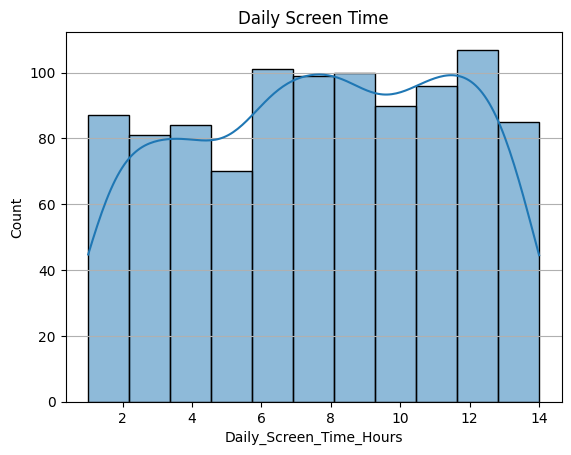

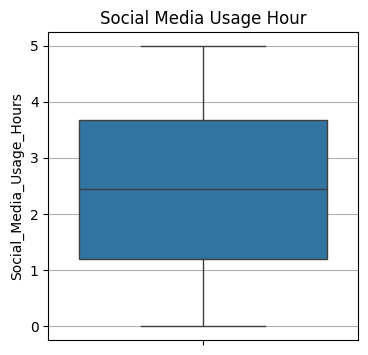

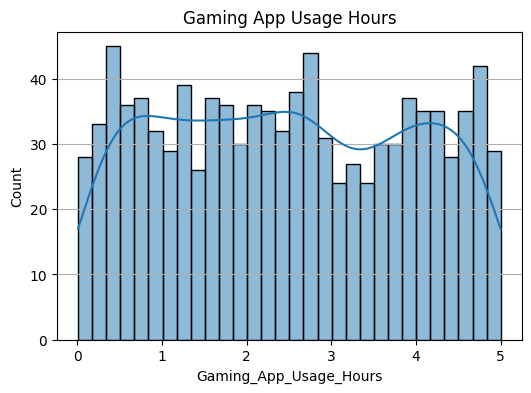

In [46]:
# Histogram
sns.histplot(data['Daily_Screen_Time_Hours'], kde=True)
plt.title("Daily Screen Time")
plt.grid(axis='y')
plt.show()

# Boxplot
plt.figure(figsize=(4,4))
sns.boxplot(data['Social_Media_Usage_Hours'])
plt.grid(axis='y')
plt.title("Social Media Usage Hour")
plt.show()

# Gaming App Usage 
plt.figure(figsize=(6,4))
sns.histplot(data['Gaming_App_Usage_Hours'], kde=True, bins=30)
plt.title("Gaming App Usage Hours")
plt.grid(axis='y')
plt.show()

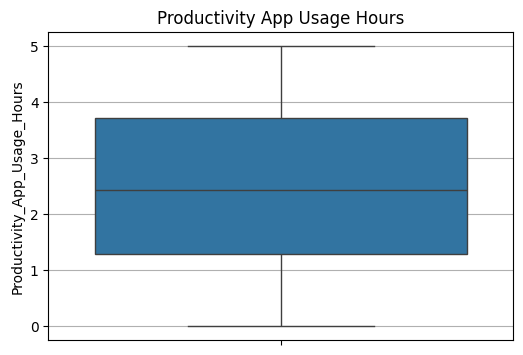

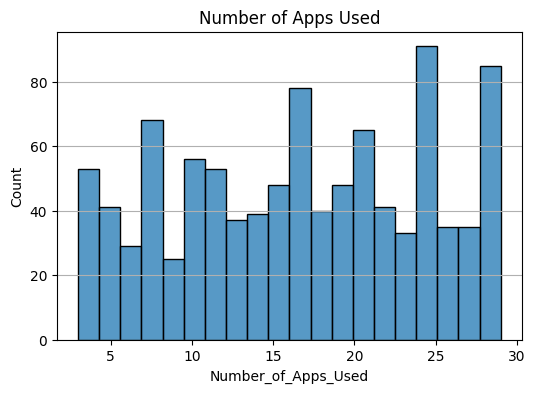

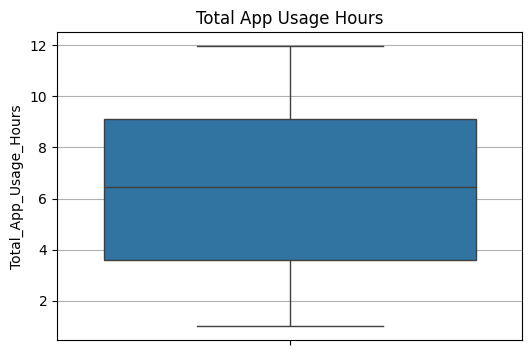

In [47]:
# Productivity App Usage 
plt.figure(figsize=(6,4))
sns.boxplot(data['Productivity_App_Usage_Hours'])
plt.title("Productivity App Usage Hours")
plt.grid(axis='y')
plt.show()

# Number of Apps Used 
plt.figure(figsize=(6,4))
sns.histplot(data['Number_of_Apps_Used'], bins=20)
plt.title("Number of Apps Used")
plt.grid(axis='y')
plt.show()

# Total App Usage Hours 
plt.figure(figsize=(6,4))
sns.boxplot(data['Total_App_Usage_Hours'])
plt.title("Total App Usage Hours")
plt.grid(axis='y')
plt.show()

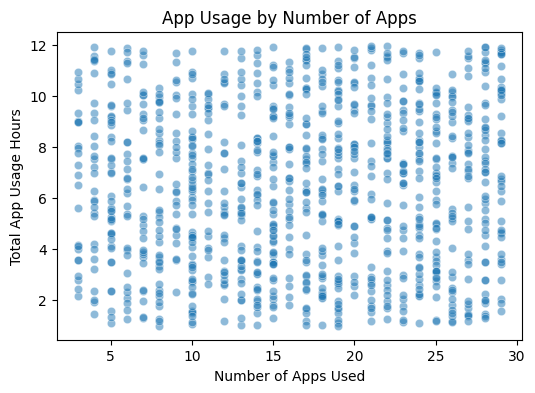

In [76]:
# Scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='Number_of_Apps_Used', y='Total_App_Usage_Hours', data=data ,alpha=0.5)
plt.title("App Usage by Number of Apps")
plt.xlabel("Number of Apps Used")
plt.ylabel("Total App Usage Hours")
plt.show()


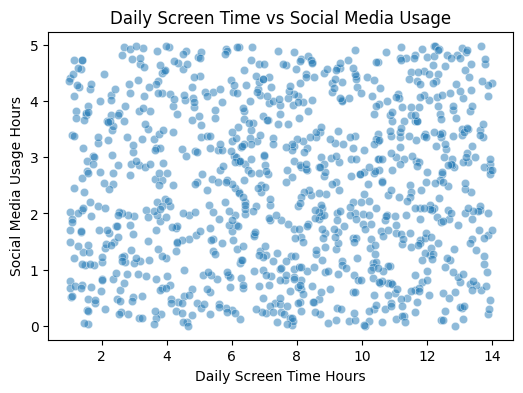

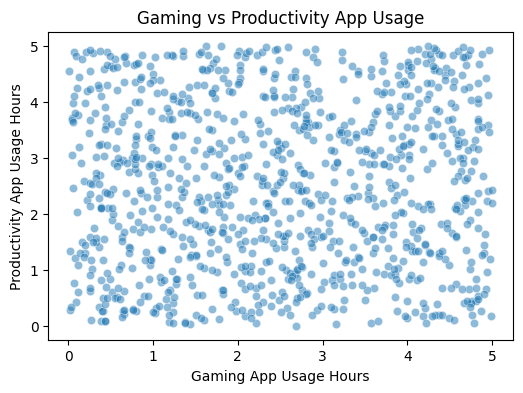

In [49]:
# Daily Screen Time vs Social Media Usage Hours
plt.figure(figsize=(6,4))
sns.scatterplot(x='Daily_Screen_Time_Hours', y='Social_Media_Usage_Hours', data=data, alpha=0.5)
plt.title("Daily Screen Time vs Social Media Usage")
plt.xlabel("Daily Screen Time Hours")
plt.ylabel("Social Media Usage Hours")
plt.show()

# Gaming App Usage vs Productivity App Usage
plt.figure(figsize=(6,4))
sns.scatterplot(x='Gaming_App_Usage_Hours', y='Productivity_App_Usage_Hours', data=data, alpha=0.5)
plt.title("Gaming vs Productivity App Usage")
plt.xlabel("Gaming App Usage Hours")
plt.ylabel("Productivity App Usage Hours")
plt.show()

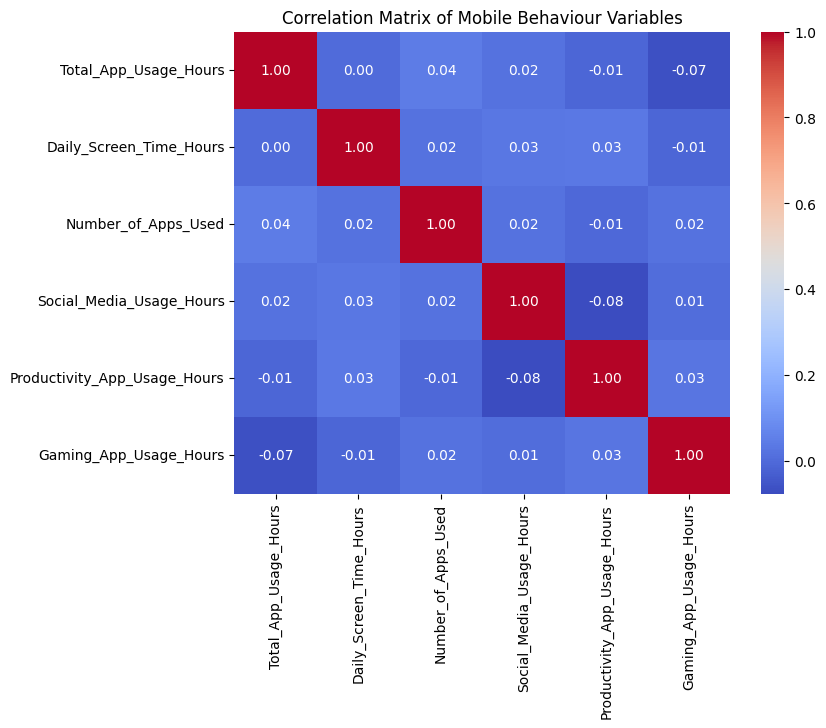

In [50]:
# Correlation Matrix 
numeric_cols = [
    'Total_App_Usage_Hours',
    'Daily_Screen_Time_Hours',
    'Number_of_Apps_Used',
    'Social_Media_Usage_Hours',
    'Productivity_App_Usage_Hours',
    'Gaming_App_Usage_Hours'
]

plt.figure(figsize=(8,6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Mobile Behaviour Variables")
plt.show()

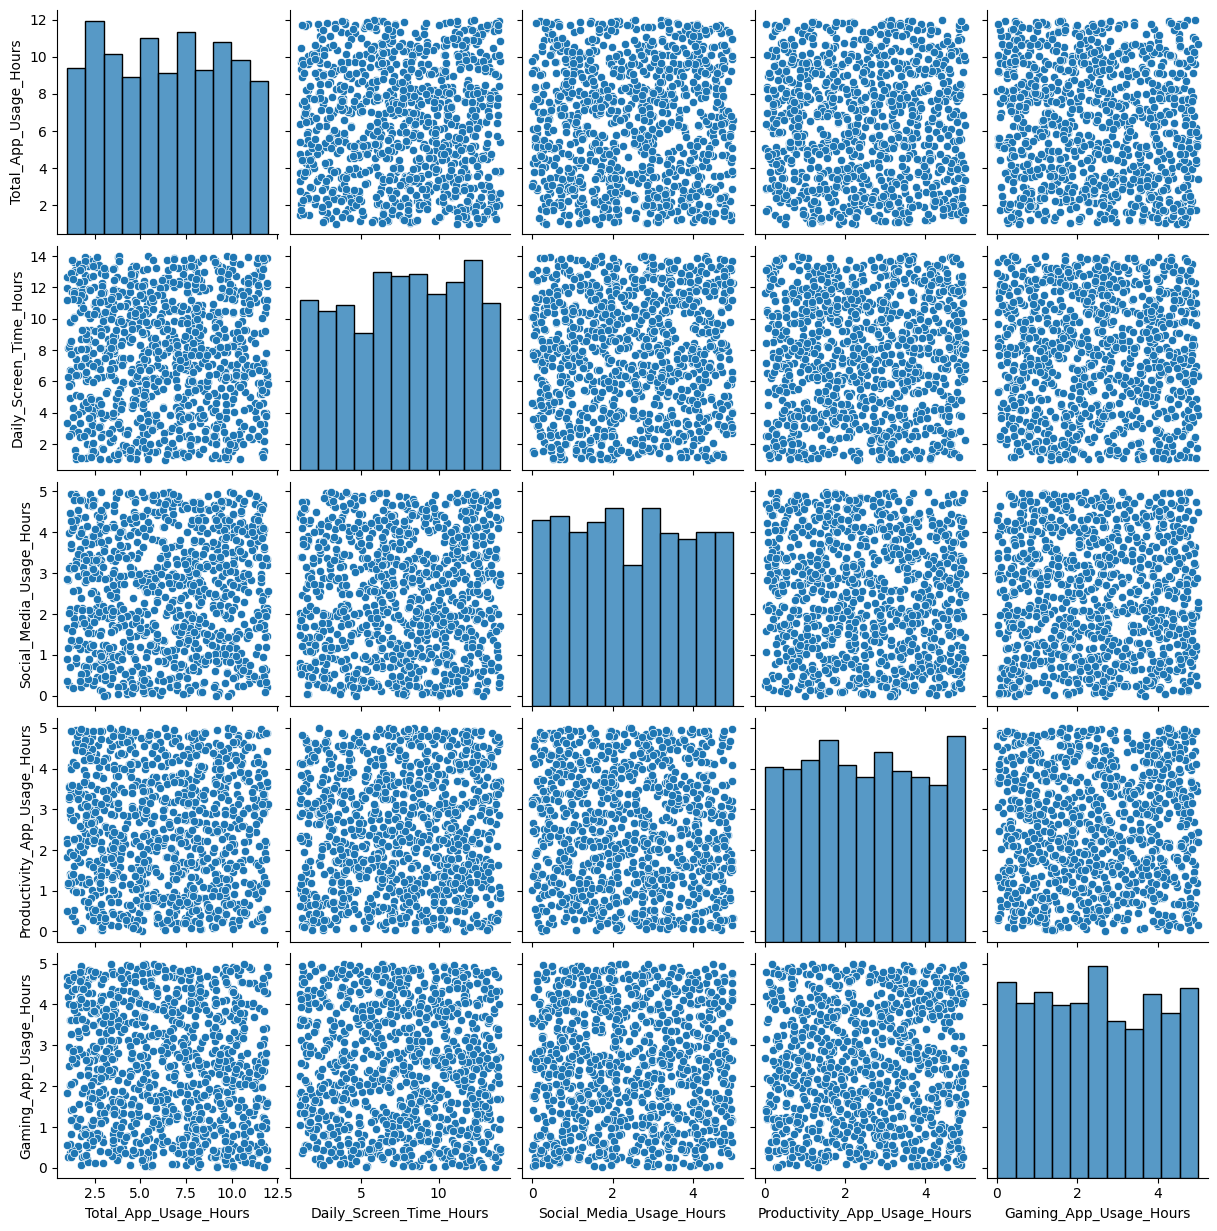

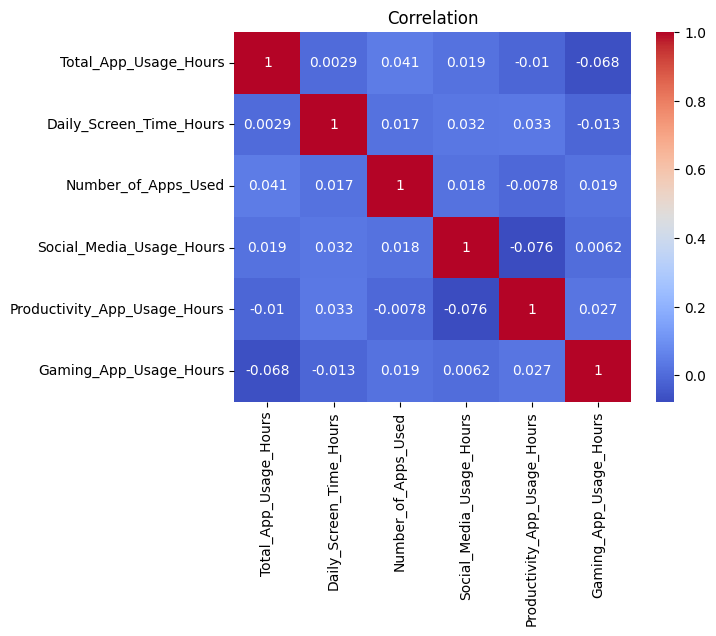

In [51]:
# Pairplot
sns.pairplot(data[['Total_App_Usage_Hours','Daily_Screen_Time_Hours',
                   'Social_Media_Usage_Hours','Productivity_App_Usage_Hours',
                   'Gaming_App_Usage_Hours']])
plt.show()

#correlation only numaric allow
sns.heatmap(data[['Total_App_Usage_Hours','Daily_Screen_Time_Hours',
                  'Number_of_Apps_Used','Social_Media_Usage_Hours',
                  'Productivity_App_Usage_Hours','Gaming_App_Usage_Hours']].corr(),annot=True, cmap="coolwarm")

plt.title("Correlation")
plt.show()

# Handling Missing Data and Outliers

In [52]:
print("Missing Values Check:")
display(data.isnull().sum())

print("\nChack duplicat value:")
display(data.duplicated().sum())

#Gender Distribution
display(data['Gender'].value_counts())
print("\n")

# Location distribution
display(data['Location'].value_counts())

Missing Values Check:


User_ID                         0
Age                             0
Gender                          0
Total_App_Usage_Hours           0
Daily_Screen_Time_Hours         0
Number_of_Apps_Used             0
Social_Media_Usage_Hours        0
Productivity_App_Usage_Hours    0
Gaming_App_Usage_Hours          0
Location                        0
dtype: int64


Chack duplicat value:


np.int64(0)

Gender
Male      517
Female    483
Name: count, dtype: int64

Location
New York       243
Phoenix        199
Chicago        192
Los Angeles    185
Houston        181
Name: count, dtype: int64

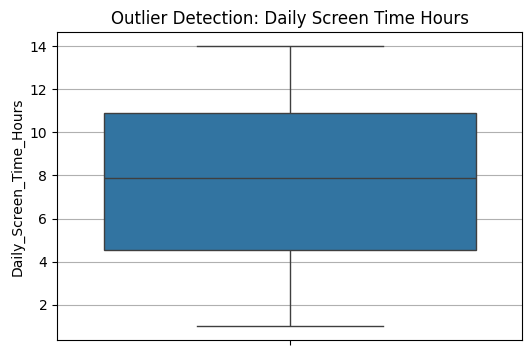

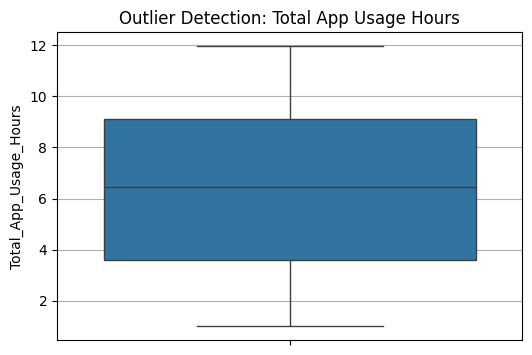

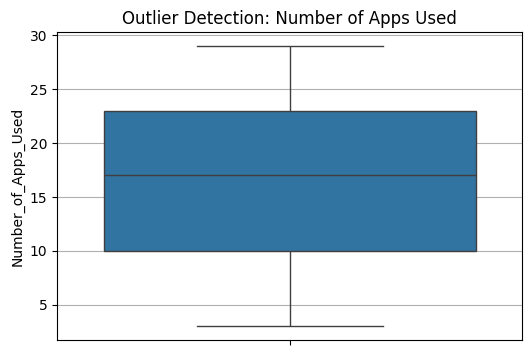

In [53]:
# Box Plot - Outliers Detection
plt.figure(figsize=(6,4))
sns.boxplot(data['Daily_Screen_Time_Hours'])
plt.title("Outlier Detection: Daily Screen Time Hours")
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data['Total_App_Usage_Hours'])
plt.title("Outlier Detection: Total App Usage Hours")
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data['Number_of_Apps_Used'])
plt.title("Outlier Detection: Number of Apps Used")
plt.grid(axis='y')
plt.show()

# Spread of Data

In [54]:
#mean
print("\n          Mean")
display(data[['Age', 'Total_App_Usage_Hours', 'Daily_Screen_Time_Hours', 
              'Number_of_Apps_Used', 'Social_Media_Usage_Hours',
              'Productivity_App_Usage_Hours', 'Gaming_App_Usage_Hours']].mean())
#median
print("\n          Median")
display(data[['Age', 'Total_App_Usage_Hours', 'Daily_Screen_Time_Hours', 
              'Number_of_Apps_Used', 'Social_Media_Usage_Hours',
              'Productivity_App_Usage_Hours', 'Gaming_App_Usage_Hours']].median())
#mode
print("\n          Mode")
display(data[['Gender', 'Location']].mode())

# Standard Deviation
print("\nStandard Deviation:")
display(data[['Age', 'Total_App_Usage_Hours', 'Daily_Screen_Time_Hours', 
              'Number_of_Apps_Used', 'Social_Media_Usage_Hours',
              'Productivity_App_Usage_Hours', 'Gaming_App_Usage_Hours']].std())

# Skewness
print("\nSkewness:")
display(data[['Age', 'Total_App_Usage_Hours', 'Daily_Screen_Time_Hours', 
              'Number_of_Apps_Used', 'Social_Media_Usage_Hours',
              'Productivity_App_Usage_Hours', 'Gaming_App_Usage_Hours']].skew())

# Kurtosis
print("\nKurtosis:")
display(data[['Age', 'Total_App_Usage_Hours', 'Daily_Screen_Time_Hours', 
              'Number_of_Apps_Used', 'Social_Media_Usage_Hours',
              'Productivity_App_Usage_Hours', 'Gaming_App_Usage_Hours']].kurt())



          Mean


Age                             38.74500
Total_App_Usage_Hours            6.40567
Daily_Screen_Time_Hours          7.69631
Number_of_Apps_Used             16.64700
Social_Media_Usage_Hours         2.45633
Productivity_App_Usage_Hours     2.49527
Gaming_App_Usage_Hours           2.47541
dtype: float64


          Median


Age                             40.000
Total_App_Usage_Hours            6.455
Daily_Screen_Time_Hours          7.880
Number_of_Apps_Used             17.000
Social_Media_Usage_Hours         2.445
Productivity_App_Usage_Hours     2.435
Gaming_App_Usage_Hours           2.455
dtype: float64


          Mode


...

Age                             12.186734
Total_App_Usage_Hours            3.134855
Daily_Screen_Time_Hours          3.714187
Number_of_Apps_Used              7.619610
Social_Media_Usage_Hours         1.439525
Productivity_App_Usage_Hours     1.443392
Gaming_App_Usage_Hours           1.450362
dtype: float64


Skewness:


Age                            -0.089459
Total_App_Usage_Hours           0.024755
Daily_Screen_Time_Hours        -0.106918
Number_of_Apps_Used            -0.081492
Social_Media_Usage_Hours        0.040911
Productivity_App_Usage_Hours    0.035949
Gaming_App_Usage_Hours          0.046244
dtype: float64


Kurtosis:


Age                            -1.222408
Total_App_Usage_Hours          -1.181391
Daily_Screen_Time_Hours        -1.142901
Number_of_Apps_Used            -1.150048
Social_Media_Usage_Hours       -1.192722
Productivity_App_Usage_Hours   -1.188312
Gaming_App_Usage_Hours         -1.218610
dtype: float64

# Automating EDA

In [55]:
def automated(df):
    print("\nSummary:")
    display(df.describe())
    
    print("\nDataset Info:")
    display(df.info())

    print("\nMissing Values Check:")
    display(df.isnull().sum())

    print("\nCorrelation:")
    display(df.corr(numeric_only=True))

automated(data)


Summary:


,User_ID,Age,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,38.745000,6.405670,7.696310,16.64700,2.456330,2.495270,2.475410
std,288.819436,12.186734,3.134855,3.714187,7.61961,1.439525,1.443392,1.450362
min,1.000000,18.000000,1.000000,1.010000,3.00000,0.000000,0.000000,0.010000
25%,250.750000,28.000000,3.590000,4.530000,10.00000,1.200000,1.282500,1.220000
50%,500.500000,40.000000,6.455000,7.880000,17.00000,2.445000,2.435000,2.455000
75%,750.250000,50.000000,9.122500,10.910000,23.00000,3.672500,3.710000,3.782500
max,1000.000000,59.000000,11.970000,14.000000,29.00000,4.990000,5.000000,5.000000



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   object 
 3   Total_App_Usage_Hours         1000 non-null   float64
 4   Daily_Screen_Time_Hours       1000 non-null   float64
 5   Number_of_Apps_Used           1000 non-null   int64  
 6   Social_Media_Usage_Hours      1000 non-null   float64
 7   Productivity_App_Usage_Hours  1000 non-null   float64
 8   Gaming_App_Usage_Hours        1000 non-null   float64
 9   Location                      1000 non-null   object 
dtypes: float64(5), int64(3), object(2)
memory usage: 78.3+ KB


None


Missing Values Check:


User_ID                         0
Age                             0
Gender                          0
Total_App_Usage_Hours           0
Daily_Screen_Time_Hours         0
Number_of_Apps_Used             0
Social_Media_Usage_Hours        0
Productivity_App_Usage_Hours    0
Gaming_App_Usage_Hours          0
Location                        0
dtype: int64


Correlation:


,User_ID,Age,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours
User_ID,1.000000,-0.028576,-0.010570,0.020941,-0.001214,-0.002608,0.002207,-0.003514
Age,-0.028576,1.000000,-0.003319,-0.017639,-0.002081,-0.008324,0.005848,-0.012969
Total_App_Usage_Hours,-0.010570,-0.003319,1.000000,0.002948,0.041493,0.019330,-0.009983,-0.067770
Daily_Screen_Time_Hours,0.020941,-0.017639,0.002948,1.000000,0.016835,0.031773,0.033206,-0.012984
Number_of_Apps_Used,-0.001214,-0.002081,0.041493,0.016835,1.000000,0.017789,-0.007814,0.019468
Social_Media_Usage_Hours,-0.002608,-0.008324,0.019330,0.031773,0.017789,1.000000,-0.076456,0.006217
Productivity_App_Usage_Hours,0.002207,0.005848,-0.009983,0.033206,-0.007814,-0.076456,1.000000,0.027217
Gaming_App_Usage_Hours,-0.003514,-0.012969,-0.067770,-0.012984,0.019468,0.006217,0.027217,1.000000


# Regression Analysis 

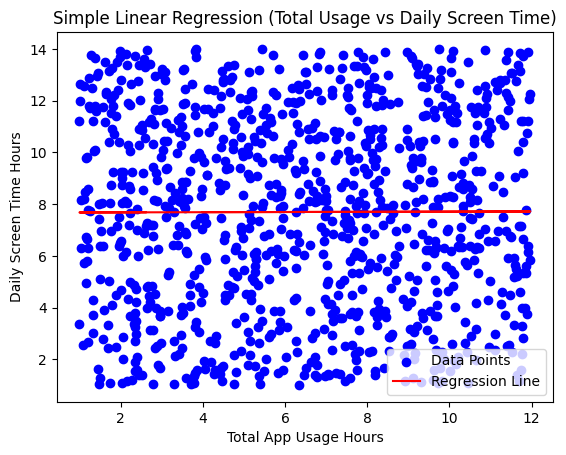

Covariance:



,Total_App_Usage_Hours,Daily_Screen_Time_Hours
Total_App_Usage_Hours,9.827318,0.034325
Daily_Screen_Time_Hours,0.034325,13.795185


Correlation:



,Total_App_Usage_Hours,Daily_Screen_Time_Hours
Total_App_Usage_Hours,1.000000,0.002948
Daily_Screen_Time_Hours,0.002948,1.000000


In [57]:
X = data[['Total_App_Usage_Hours']]
y = data['Daily_Screen_Time_Hours']


reg_usage = LinearRegression()
reg_usage.fit(X, y)

# Scatter plot with regression line
plt.scatter(X, y, color='blue', label="Data Points")
plt.plot(X, reg_usage.predict(X), color='red', label="Regression Line")
plt.xlabel("Total App Usage Hours")
plt.ylabel("Daily Screen Time Hours")
plt.title("Simple Linear Regression (Total Usage vs Daily Screen Time)")
plt.legend()
plt.show()

# Covariance and Correlation 
print("Covariance:\n")
display(data[['Total_App_Usage_Hours','Daily_Screen_Time_Hours']].cov())

print("Correlation:\n")
display(data[['Total_App_Usage_Hours','Daily_Screen_Time_Hours']].corr())

# Supervised Learning – Regression Model

In [63]:
X = data[['Daily_Screen_Time_Hours']]   
y = data['Total_App_Usage_Hours']      

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [64]:
# Simple Linear Regression
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

print("Train R²:", reg_model.score(X_train, y_train))
print("Validation R²:", reg_model.score(X_val, y_val))
print("Test R²:", reg_model.score(X_test, y_test))

Train R²: 0.00018223572344155947
Validation R²: -0.002868546087509305
Test R²: 0.0012787452702611724


In [65]:
# Multi Linear Regression
X_multi = data[['Daily_Screen_Time_Hours','Number_of_Apps_Used']]
y_multi = data['Total_App_Usage_Hours']

X_train_m, X_temp_m, y_train_m, y_temp_m = train_test_split(X_multi, y_multi, test_size=0.4, random_state=42)
X_val_m, X_test_m, y_val_m, y_test_m = train_test_split(X_temp_m, y_temp_m, test_size=0.5, random_state=42)

reg_multi = LinearRegression()
reg_multi.fit(X_train_m, y_train_m)

print("Multi Train R²:", reg_multi.score(X_train_m, y_train_m))
print("Multi Validation R²:", reg_multi.score(X_val_m, y_val_m))
print("Multi Test R²:", reg_multi.score(X_test_m, y_test_m))


Multi Train R²: 0.0013414235132643837
Multi Validation R²: 0.0012107345560741223
Multi Test R²: 0.0020350396708257446


In [66]:
# Logistic Regression
data['Usage_Category'] = (data['Total_App_Usage_Hours'] > data['Total_App_Usage_Hours'].mean()).astype(int)

X_clf = data[['Daily_Screen_Time_Hours','Number_of_Apps_Used']]
y_clf = data['Usage_Category']

X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(X_clf, y_clf, test_size=0.4, random_state=42)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(X_temp_c, y_temp_c, test_size=0.5, random_state=42)

clf_model = LogisticRegression()
clf_model.fit(X_train_c, y_train_c)

y_val_pred = clf_model.predict(X_val_c)
y_test_pred = clf_model.predict(X_test_c)

print("Validation Accuracy:", accuracy_score(y_val_c, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test_c, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_test_pred))
print("Classification Report:\n", classification_report(y_test_c, y_test_pred))

Validation Accuracy: 0.525
Test Accuracy: 0.495
Confusion Matrix:
 [[51 45]
 [56 48]]
Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.53      0.50        96
           1       0.52      0.46      0.49       104

    accuracy                           0.49       200
   macro avg       0.50      0.50      0.49       200
weighted avg       0.50      0.49      0.49       200



# Overfitting and Underfitting 

In [67]:
print("Simple Regression:")
print("Train R²:",reg_model.score(X_train, y_train))
print("Test R²:",reg_model.score(X_test, y_test))

print("\nMulti Regression:")
print("Train R²:",reg_multi.score(X_train_m, y_train_m))
print("Test R²:",reg_multi.score(X_test_m, y_test_m))

Simple Regression:
Train R²: 0.00018223572344155947
Test R²: 0.0012787452702611724

Multi Regression:
Train R²: 0.0013414235132643837
Test R²: 0.0020350396708257446


# Classification

In [68]:
#Classification 
y_pred_clf = clf_model.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_clf))
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test_c, y_pred_clf),
                     index=['Actual 0','Actual 1'],
                     columns=['Predicted 0','Predicted 1']))
print("\nClassification:")
print(classification_report(y_test_c, y_pred_clf))

Accuracy: 0.495

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,51,45
Actual 1,56,48



Classification:
              precision    recall  f1-score   support

           0       0.48      0.53      0.50        96
           1       0.52      0.46      0.49       104

    accuracy                           0.49       200
   macro avg       0.50      0.50      0.49       200
weighted avg       0.50      0.49      0.49       200



# Model Evaluation

In [69]:
# Model Evaluation

 # Regression
y_pred_reg = reg_model.predict(X_test)
print("Regression Evaluation")
print("MSE:", mean_squared_error(y_test, y_pred_reg))
print("MAE:", mean_absolute_error(y_test, y_pred_reg))
print("R²:", r2_score(y_test, y_pred_reg))

 # Classification
y_pred_clf = clf_model.predict(X_test_c)
print("\nClassification Evaluation")
print("Accuracy:", accuracy_score(y_test_c, y_pred_clf))
print("Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test_c, y_pred_clf),
                     index=['Actual 0','Actual 1'],
                     columns=['Predicted 0','Predicted 1']))
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_clf))

Regression Evaluation
MSE: 9.658166329833492
MAE: 2.6768532742744187
R²: 0.0012787452702611724

Classification Evaluation
Accuracy: 0.495
Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,51,45
Actual 1,56,48



Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.53      0.50        96
           1       0.52      0.46      0.49       104

    accuracy                           0.49       200
   macro avg       0.50      0.50      0.49       200
weighted avg       0.50      0.49      0.49       200



In [70]:
# Regression Evaluation
y_pred_reg = reg_model.predict(X_test)
print("Regression Evaluation")
print("MSE:", mean_squared_error(y_test, y_pred_reg))
print("MAE:", mean_absolute_error(y_test, y_pred_reg))
print("R²:", r2_score(y_test, y_pred_reg))

Regression Evaluation
MSE: 9.658166329833492
MAE: 2.6768532742744187
R²: 0.0012787452702611724


# Data visualization

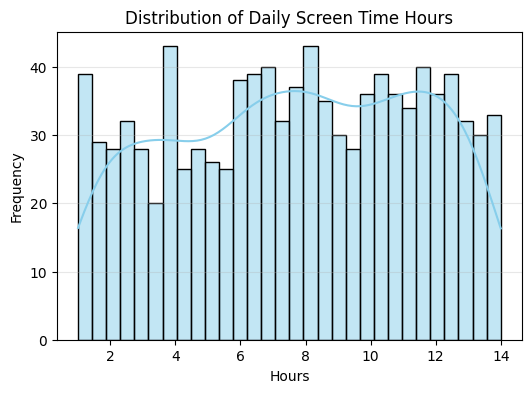

Skewness of Daily Screen Time Hours: -0.11


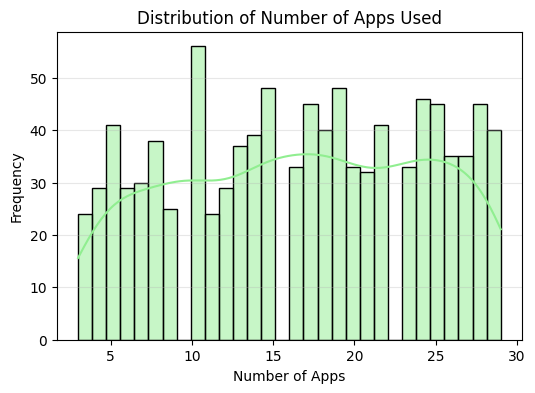

Skewness of Number_of_Apps_Used: -0.08


In [71]:
#Daily Screen Time Hours
plt.figure(figsize=(6,4))
sns.histplot(data['Daily_Screen_Time_Hours'], kde=True, bins=30, color="skyblue")
plt.title("Distribution of Daily Screen Time Hours")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Skewness of Daily Screen Time Hours: {data['Daily_Screen_Time_Hours'].skew():.2f}")

#Number of Apps Used
plt.figure(figsize=(6,4))
sns.histplot(data['Number_of_Apps_Used'], kde=True, bins=30, color="lightgreen")
plt.title("Distribution of Number of Apps Used")
plt.xlabel("Number of Apps")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Skewness of Number_of_Apps_Used: {data['Number_of_Apps_Used'].skew():.2f}")


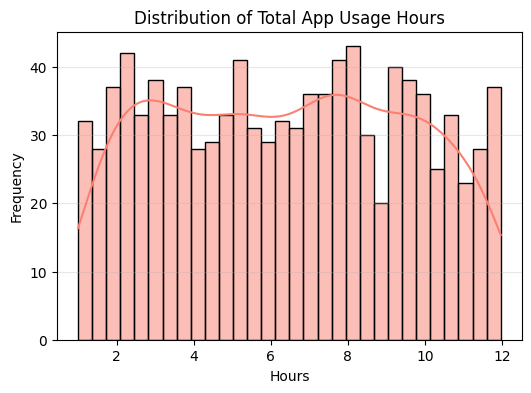

Skewness of Total_App_Usage_Hours: 0.02


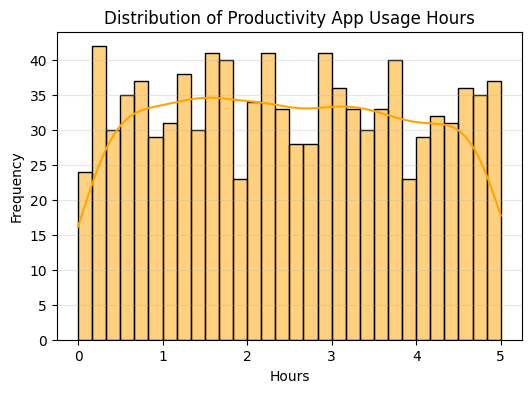

Skewness of Productivity_App_Usage_Hours: 0.04


In [72]:
#Total App Usage Hours
plt.figure(figsize=(6,4))
sns.histplot(data['Total_App_Usage_Hours'], kde=True, bins=30, color="salmon")
plt.title("Distribution of Total App Usage Hours")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Skewness of Total_App_Usage_Hours: {data['Total_App_Usage_Hours'].skew():.2f}")

#Productivity App Usage Hours
plt.figure(figsize=(6,4))
sns.histplot(data['Productivity_App_Usage_Hours'], kde=True, bins=30, color="Orange")
plt.title("Distribution of Productivity App Usage Hours")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Skewness of Productivity_App_Usage_Hours: {data['Productivity_App_Usage_Hours'].skew():.2f}")

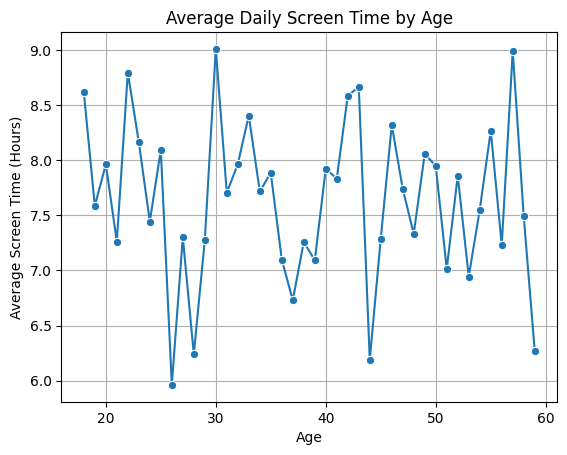

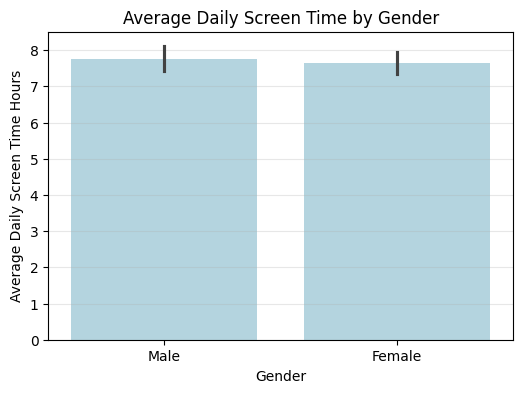

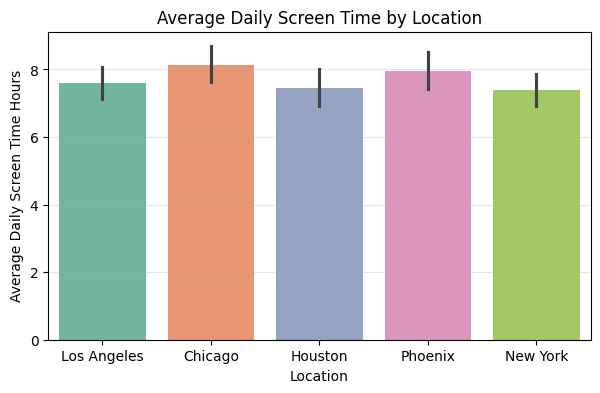

In [73]:
#verage Daily Screen Time by Age
avg_data = data.groupby('Age')['Daily_Screen_Time_Hours'].mean().reset_index()

sns.lineplot(data=avg_data, x='Age', y='Daily_Screen_Time_Hours', marker='o')
plt.title('Average Daily Screen Time by Age')
plt.xlabel('Age')
plt.ylabel('Average Screen Time (Hours)')
plt.grid(True)
plt.show()


#Average Daily Screen Time by Gender
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Daily_Screen_Time_Hours', data=data, estimator=np.mean, color="lightblue")
plt.title("Average Daily Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Daily Screen Time Hours")
plt.grid(axis='y', alpha=0.3)
plt.show()


#Average Daily Screen Time by Location
plt.figure(figsize=(7,4))
sns.barplot(x='Location', y='Daily_Screen_Time_Hours', data=data, estimator=np.mean, hue='Location', palette="Set2")
plt.title("Average Daily Screen Time by Location")
plt.xlabel("Location")
plt.ylabel("Average Daily Screen Time Hours")
plt.grid(axis='y', alpha=0.3)
plt.show()

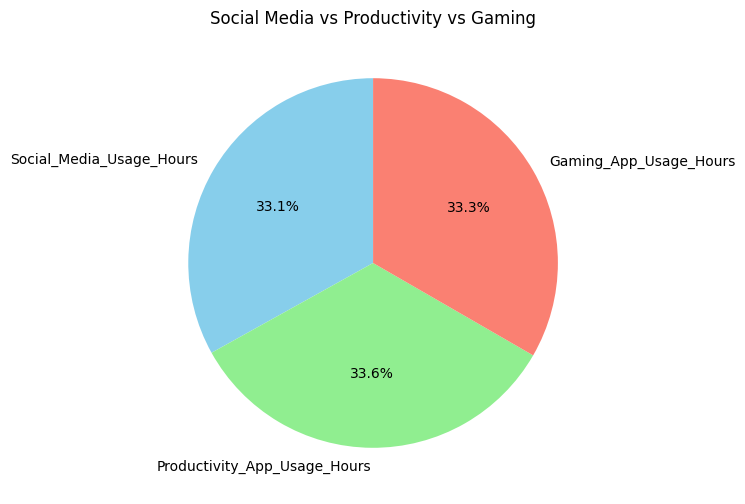

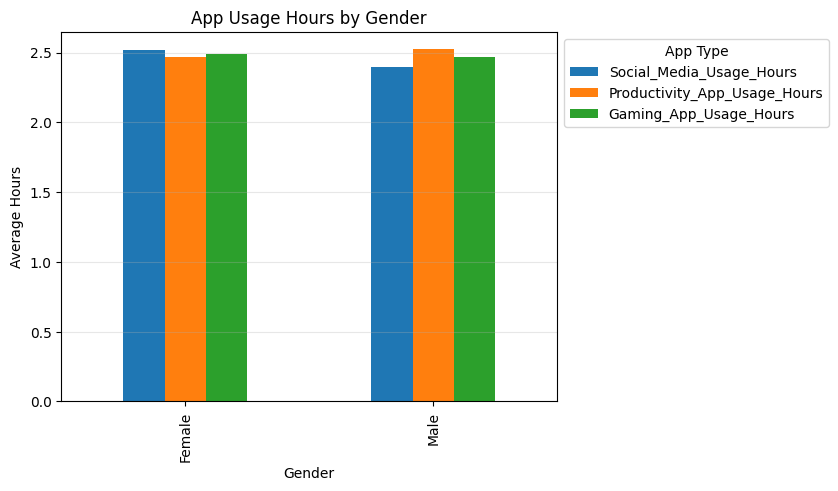

In [74]:
# average usage hours 
avg_use = data[['Social_Media_Usage_Hours',
                    'Productivity_App_Usage_Hours',
                    'Gaming_App_Usage_Hours']].mean()
# Pie chart
plt.figure(figsize=(6,6))
plt.pie(avg_use, 
        labels=avg_use.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['skyblue','lightgreen','salmon'])   

plt.title("Social Media vs Productivity vs Gaming")
plt.show()


# Grouped Bar Chart

barchart = data.groupby('Gender')[['Social_Media_Usage_Hours',
                                   'Productivity_App_Usage_Hours',
                                   'Gaming_App_Usage_Hours']].mean()

barchart.plot(kind='bar')
plt.title("App Usage Hours by Gender")
plt.ylabel("Average Hours")
plt.xlabel("Gender")
plt.legend(title="App Type", bbox_to_anchor=(1.0, 1.0))
plt.grid(axis='y', alpha=0.3)
plt.show()


<Figure size 800x500 with 0 Axes>

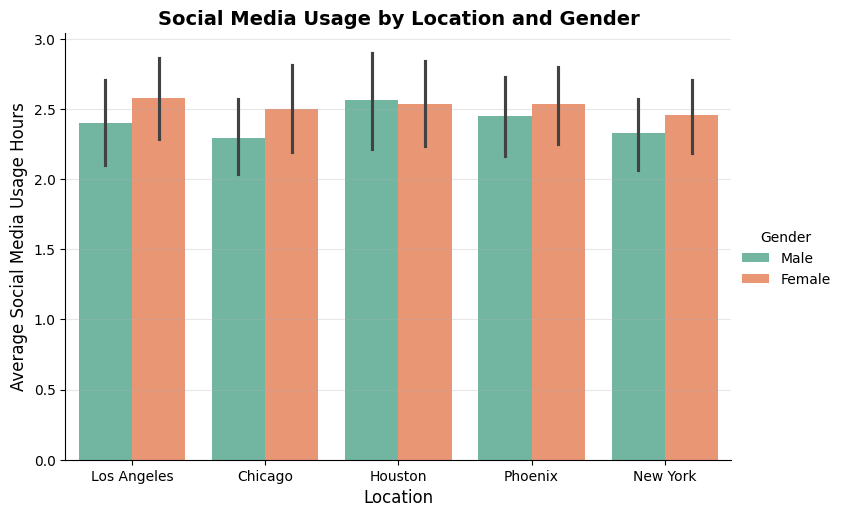

<Figure size 800x500 with 0 Axes>

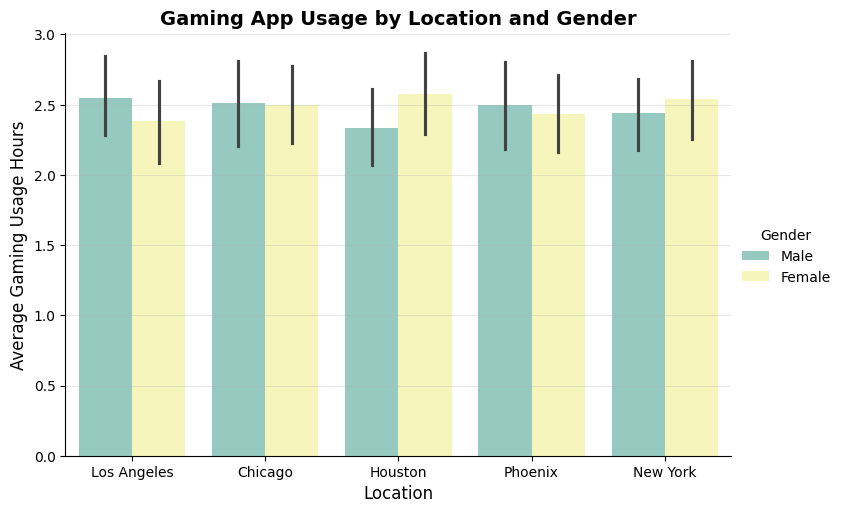

<Figure size 800x500 with 0 Axes>

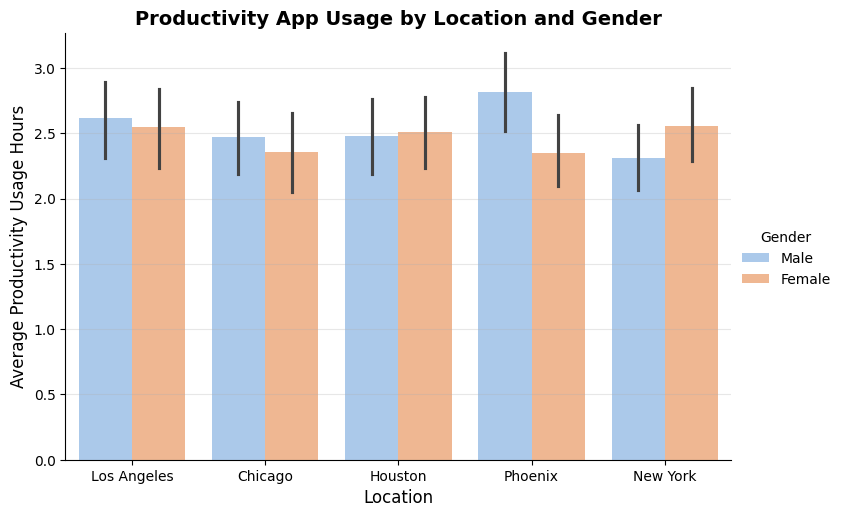

In [75]:
#catplot

#Social Media Usage by Location and Gender
plt.figure(figsize=(8,5))
sns.catplot(x="Location", y="Social_Media_Usage_Hours", hue="Gender",
            data=data, kind="bar", palette="Set2", height=5, aspect=1.5)

plt.title("Social Media Usage by Location and Gender", fontsize=14, fontweight='bold')
plt.xlabel("Location", fontsize=12)
plt.ylabel("Average Social Media Usage Hours", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()


# Gaming App Usage by Location and Gender
plt.figure(figsize=(8,5))
sns.catplot(x="Location", y="Gaming_App_Usage_Hours", hue="Gender",
            data=data, kind="bar", palette="Set3", height=5, aspect=1.5)

plt.title("Gaming App Usage by Location and Gender", fontsize=14, fontweight='bold')
plt.xlabel("Location", fontsize=12)
plt.ylabel("Average Gaming Usage Hours", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()


#"Average Productivity Usage Hours
plt.figure(figsize=(8,5))
sns.catplot(x="Location", y="Productivity_App_Usage_Hours", hue="Gender",
            data=data, kind="bar", palette="pastel", height=5, aspect=1.5)

plt.title("Productivity App Usage by Location and Gender", fontsize=14, fontweight='bold')
plt.xlabel("Location", fontsize=12)
plt.ylabel("Average Productivity Usage Hours", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()